Package import

In [36]:
!pip install numpy==1.26.4 spacy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import random
import spacy
from collections import Counter

Training data import

In [38]:
train = pd.read_csv("../data/train.csv", sep=",")
train.iloc[random.randint(0, train.shape[0])]

doc_id                                         recette_64298.xml
titre                                        Gâteau des amoureux
type                                                     Dessert
difficulte                                                Facile
cout                                                  Bon marché
ingredients    - 100 g de Nesquik - 50 g de poudre d'amandes ...
recette        Préchauffer le four à 180°C (thermostat 6). Da...
Name: 10200, dtype: object

## Exploratory Data Analysis : Train set

**Number of documents**

In [1]:
print(f"{train.shape[0]} documents")

NameError: name 'train' is not defined

**Count null column null values**

In [40]:
train.isna().sum()

doc_id         0
titre          0
type           0
difficulte     0
cout           0
ingredients    0
recette        0
dtype: int64

Il n'existe pas de données manquantes

**Type des colonnes**

**Columns content**

In [ ]:
def column_check(data):
    """Calculate duplication rate in columns"""
    nb_values = []
    duplications = []
    for column in data.columns:
        distinct_values = set(data[column])
        nb_values.append(len(distinct_values))
        purc_duplications = round(100*data[column].duplicated().sum()/data.shape[0],2)
        duplications.append(purc_duplications)
    result = pd.DataFrame({"variable":data.columns, "nb_categories":nb_values, "%duplication":duplications})
    return result
    

In [42]:
columns_stats = column_check(train)
columns_stats

,variable,nb_categories,%duplication
0,doc_id,12473,0.00
1,titre,12438,0.28
2,type,3,99.98
3,difficulte,4,99.97
4,cout,3,99.98
5,ingredients,12473,0.00
6,recette,12473,0.00


On remarque la présente de lignes dupliquée

**Duplication index**

In [43]:
titre_dupli = train[train["titre"].duplicated(keep=False) == True].drop(columns=["doc_id"])
titre_dupli.head()

,titre,type,difficulte,cout,ingredients,recette
470,Courgettes farcies au thon,Plat principal,Facile,Bon marché,- 1 grosse courgette - 1 grosse tomate - 1 oig...,Laver la courgette et la couper en deux. Enlev...
524,Tarte au citron meringuée,Dessert,Facile,Moyen,- 1 pâte brisée - 37 cl de lait - 3 jaunes d’o...,Préchauffer le four à 150°C (thermostat 5). Ne...
1132,Mousse aux spéculoos,Dessert,Très facile,Bon marché,- 400 g de spéculoos - 1/2 l de crème fraîche ...,Faire tremper la gelée à l'eau froide pour la ...
1507,Mousse aux spéculoos,Dessert,Facile,Bon marché,- 160 g de biscuits spéculoos + quelques specu...,Écraser quelques biscuits spéculoos grossièrem...
1698,Tajine tunisien,Plat principal,Facile,Bon marché,"- 500 g de viande hachée, blancs de poulet ou ...",Couper les pommes de terre en petits morceaux ...


On remarque que certaines recettes ont même titre mais n'ont ni les mêmes ingrédients, ni les mêmes méthodes de préparations. D'où l'ambiguité

**Classes distribution Vs Value occurences in columns**

In [ ]:
def columns_dist(data, cols=None):
    """Compute categories proportions in columns"""
    if not cols.items():
        return data
    for col in cols:
        cat_purcentage= round(100*data[col].value_counts(normalize=True),2)
        print(cat_purcentage, "\n")
    

In [45]:
cols = columns_stats.loc[columns_stats["%duplication"] > 99.0, "variable"]
columns_dist(train, cols)

type
Plat principal    46.52
Dessert           30.16
Entrée            23.32
Name: proportion, dtype: float64 

difficulte
Très facile              50.23
Facile                   41.49
Moyennement difficile     7.70
Difficile                 0.58
Name: proportion, dtype: float64 

cout
Bon marché    67.70
Moyen         29.06
Assez Cher     3.24
Name: proportion, dtype: float64 



Les plats ne sont pas en propositions égales. Les données sur les entrées sont sous-représentées.

In [46]:
pd.crosstab(train['type'], train['difficulte'], normalize='index')

difficulte,Difficile,Facile,Moyennement difficile,Très facile
type,,,,
Dessert,0.009835,0.384370,0.089314,0.516481
Entrée,0.002750,0.389825,0.060502,0.546923
Plat principal,0.004654,0.447260,0.077387,0.470700


La majorité des recettes sont facile ou très facile. Et la répartition (inéquitable) est la même d'une type de recette à un autre.

In [47]:
pd.crosstab(train['type'], train['cout'], normalize='index')

cout,Assez Cher,Bon marché,Moyen
type,,,
Dessert,0.011164,0.775917,0.212919
Entrée,0.051564,0.661052,0.287384
Plat principal,0.036539,0.620820,0.342640


Les recettes sont en général bon marché et la répartition du coût est la même d'un type de recette à un autre

In [ ]:
def sentence_length(sentence):
    """Compute the length of a sentence"""
    return len(sentence.split())

def sentence_freq_word(sentence):
    """Return the most common word in a sentence/document"""
    tokens = sentence.lower().split()
    freq_word = Counter(tokens).most_common(1)[0][0]
    return freq_word

def count_ingredient(document):
    """Split document on - """
    return len(document.split("-"))
    

def display_stats(data, corpus_idx=0):
    """Compute general statistics on a data"""
    corpus = data.iloc[corpus_idx]
    result = f" Recipe name :" + corpus['recipe'] + "\n Length: " + str(corpus["recipe_length"])
    result += "\n Frequent word :"+corpus["recipe_freq_word"]
    result += "\n Class: " + corpus["class"] 
    return result 	
    

'\ndef text_length(data, columns =[]):\n \n    sentences_length = {}\n    if not columns:\n        columns = list(data.columns)\n    if columns:\n        for column in columns:\n            if\n            try:\n                word_count = [np.min(data[column].apply(sentence_length)), \n                np.max(data[column].apply(sentence_length))]\n                sentences_length.append((column, word_count))\n            except KeyError as e:\n                print(f"{e} n\'est pas une colonne valide")\n        return sentences_length\n    return data\n'

In [49]:
data = pd.DataFrame({"recipe": train["titre"],
                     "title_length": train["titre"].apply(sentence_length),
                     "recipe_length": train["recette"].apply(sentence_length),
                     "ingredients_length": train["ingredients"].apply(sentence_length),
                     "recipe_freq_word": train["recette"].apply(sentence_freq_word),
                     "number_of_ingredient": train["ingredients"].apply(count_ingredient),
                     "class": train["type"]
        })
data.head()

,recipe,title_length,recipe_length,ingredients_length,recipe_freq_word,number_of_ingredient,class
0,"Feuilleté de saumon et de poireau, sauce aux c...",9,200,57,le,13,Plat principal
1,Cake poulet/moutarde/amandes,2,92,63,la,12,Entrée
2,Bûche à la truite fumée (7ème rencontre),7,139,33,de,6,Entrée
3,Gâteau au yaourt au coco sans huile de laetitia,9,44,41,dans,9,Dessert
4,Crêpes au canard laqué,4,267,85,et,15,Entrée


**Recipe min|avg|max length**

In [50]:
data["recipe_length"].apply("mean")

123.5514310911569

In [51]:
data["recipe_length"].apply("max")

1334

In [52]:
data["recipe_length"].apply("min")

9

Les plans de recettes ont entre 9 et 1334 mots

**Corpus infos**

In [53]:
print(display_stats(data, 2))

 Recipe name :Bûche à la truite fumée (7ème rencontre)
 Length: 139
 Frequent word :de
 Class: Entrée


**Most common tokens**

In [54]:
Counter(list(pd.DataFrame(data)["recipe_freq_word"])).most_common(3)

[('de', 2969), ('les', 2849), ('le', 2782)]

In [55]:
sentence_freq_word(" ".join(train["recette"]))


'de'

In [56]:
len(set(data["recipe_freq_word"]))

72

In [57]:
import seaborn as sb

In [58]:
import matplotlib.pyplot as plt

In [ ]:
def count_outliers(data):
    """Display recipes' plan length BoxPlot using quartiles"""
    res = []
    data = data.select_dtypes(exclude="object")
    for col in data.columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outlier_purcentage = round(100*data.loc[ data[col]>upper_bound ].shape[0]/ data.shape[0], 2)
        res.append((col, lower_bound, upper_bound, outlier_purcentage))
    return res
            

In [60]:
print(count_outliers(data))

[('title_length', 1.0, 9.0, 2.62), ('recipe_length', -21.0, 251.0, 4.31), ('ingredients_length', -3.0, 93.0, 3.51), ('number_of_ingredient', 1.0, 17.0, 2.57)]


<Axes: title={'center': 'Recipe boxplot'}, xlabel='class', ylabel='recipe_length'>

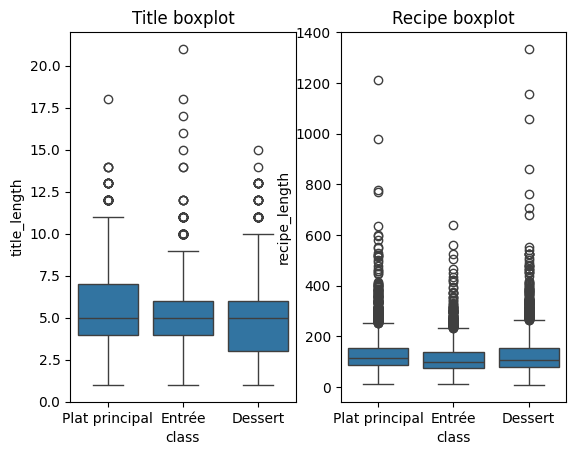

In [61]:
fig, axes = plt.subplots(1,2)
axes[0].set_title("Title boxplot")
sb.boxplot(data=data, x="class", y="title_length", ax=axes[0])
axes[1].set_title("Recipe boxplot")
sb.boxplot(data=data, x="class", y="recipe_length", ax=axes[1])

Les digrammes ci-dessus montrent que les titres des recettes ont en moyenne 5 et les recettes 150 mots environ. Toutefefois certains titres s'éloignent de la moyenne et peuvent atteindre jusqu'à 18 mots et les recettes plus de 1300 mots.

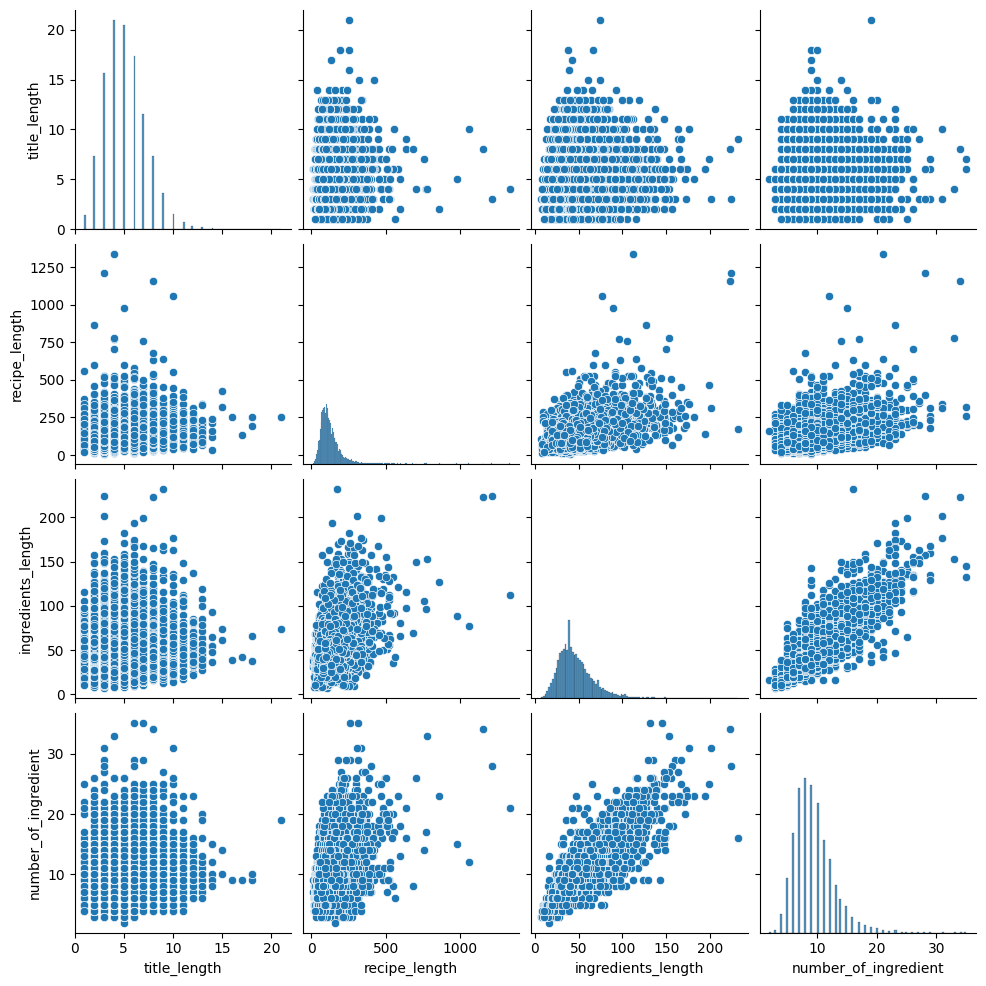

In [62]:
cp = data.select_dtypes(exclude="object")
sb.pairplot(cp)

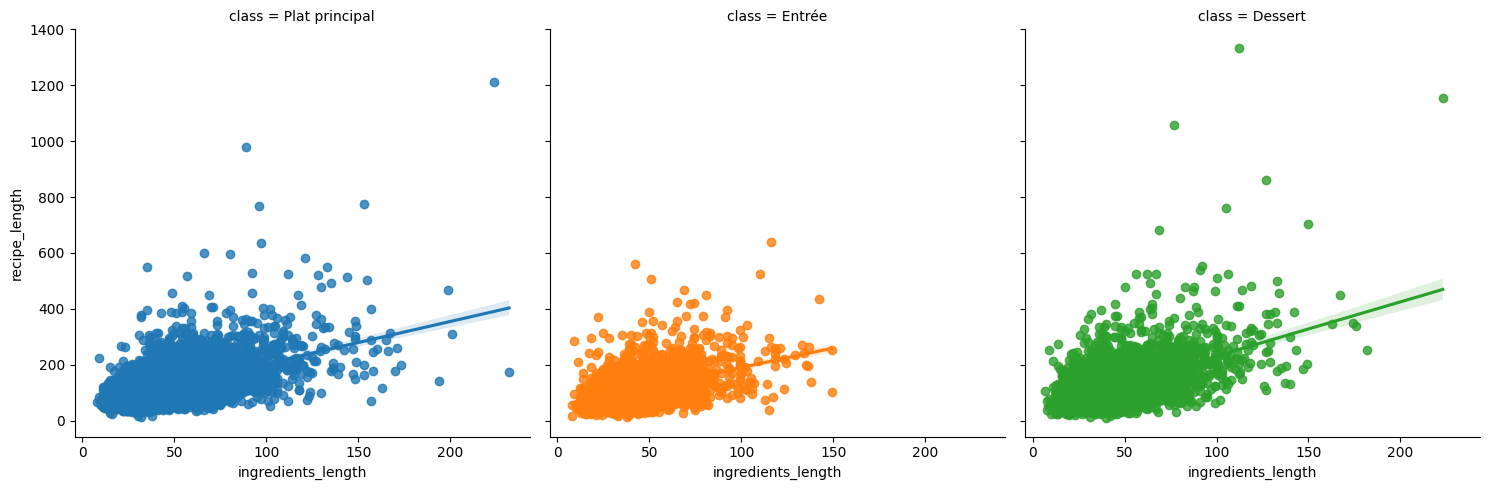

In [63]:
sb.lmplot(data=data,x="ingredients_length", y="recipe_length", hue="class", col="class")

Les longueurs des recettes ont une tendance qui semble linéaire (peut être remis en cause)

<Axes: xlabel='ingredients_length', ylabel='recipe_length'>

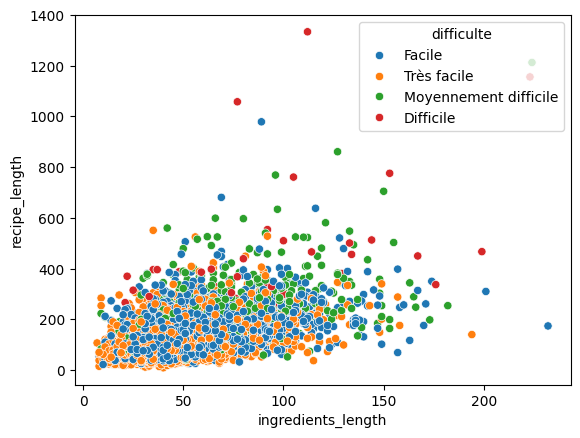

In [64]:
sb.scatterplot(data, x="ingredients_length",y="recipe_length", hue=train["difficulte"])

## Data Transformation

In [65]:
spacy.cli.download("fr_core_news_sm")
nlp = spacy.load("fr_core_news_sm")

✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [4]:
def spacy_tokenizer(text, remove_stop_words=True, lemmatize=True, min_len=1, display=True):
    spacy_tokens = nlp(text)
    lems = []
    tokens = []
    """ if remove_stop_words:
      tokens = [token.text for token in spacy_tokens if not nlp.vocab[token.text].is_stop]
    else:
      tokens = [token for token in spacy_tokens ] 
    """
    for token in spacy_tokens:
        if token.is_space or token.is_punct:
            continue
        if nlp.vocab[token.text].is_stop:
            continue
        if len(token.text) < min_len:
            continue

        token_lemma = token.lemma_ if lemmatize else token.text
        token_lemma = token_lemma.lower().strip()
        lems.append(token_lemma)
        tokens.append(token)
    if display:
        print(f"Nombre total de tokens:{len(lems)}\n\
            Nombre de mots distinct: {len(set(lems))}\n\
            Mots apparaissant au moins une fois: {set(lems)} \n\
            Mots plus fréquents: {Counter(lems).most_common(5)}\n\
            Mots: {lems}")
    return tokens, lems

In [67]:
train["clean_recette"] = train['recette'].apply(lambda tw: ' '.join(spacy_tokenizer(tw, True, True, 1, False)[1]))

In [68]:
train["clean_ingredients"] = train['ingredients'].apply(lambda tw: ' '.join(spacy_tokenizer(tw, True, True, 1, False)[1]))

In [69]:
train.drop(columns=["doc_id"]).head(3)

,titre,type,difficulte,cout,ingredients,recette,clean_recette,clean_ingredients
0,"Feuilleté de saumon et de poireau, sauce aux c...",Plat principal,Facile,Moyen,- 1 gros pavé de saumon - 100 g de crevettes d...,Couper finement le blanc et un peu de vert des...,couper finement blanc vert poireau rondell épl...,1 gros pavé saumon 100 gramme crevette décorti...
1,Cake poulet/moutarde/amandes,Entrée,Très facile,Bon marché,- 3 œufs - 150 g de farine - 1 sachet de levur...,"Couper finement l'échalote, la faire revenir à...",couper finement échalote faire revenir poêle h...,3 œuf 150 gramme farine 1 sachet levure 10 cl ...
2,Bûche à la truite fumée (7ème rencontre),Entrée,Moyennement difficile,Assez Cher,- 800 g de filet de truite saumonnée fumée en ...,Faites blanchir les épinards à l'eau bouillant...,faites blanchir épinard eau bouillant saler eg...,800 gramme filet truite saumonnée fumé tranche...


In [70]:
train.drop(columns=["doc_id"]).to_csv("../data/clean_train.csv", index=False)

**Specificity in Classifications**

In [71]:
def lexical_specificity(sentences):
    pos_counts = Counter()
    for sentence in sentences:
        tokens = nlp(sentence)
        pos_counts.update(token.pos_ for token in tokens)
    return pos_counts

In [72]:
dessert = train.loc[train["type"]=='Dessert', "clean_recette"].tolist()
specificity_dessert = lexical_specificity(dessert)


In [73]:
plat_principal = train.loc[train["type"]=='Plat principal', "clean_recette"].tolist()
specificity_plat = lexical_specificity(plat_principal)

In [74]:
entree = train.loc[train["type"]=='Entrée', "clean_recette"].tolist()
specificity_entree = lexical_specificity(entree)

In [75]:
specificity_gen = specificity_dessert + specificity_entree + specificity_plat

In [76]:
from wordcloud import WordCloud

In [ ]:
def wordcloud_display(counter, name=None):
    """Compute the word cloud given a counter"""
    freqs = counter
    if name is None:
        name = ""
    wc = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate_from_frequencies(freqs)
    return wc

In [78]:
entree_wc = wordcloud_display(specificity_entree, name="Specificité entrée")
plat_wc = wordcloud_display(specificity_plat, name="Specificité plat")
dessert_wc = wordcloud_display(specificity_dessert, name="Specificité Dessert")
all_dishes_wc = wordcloud_display(specificity_gen, name="Specificité globale")

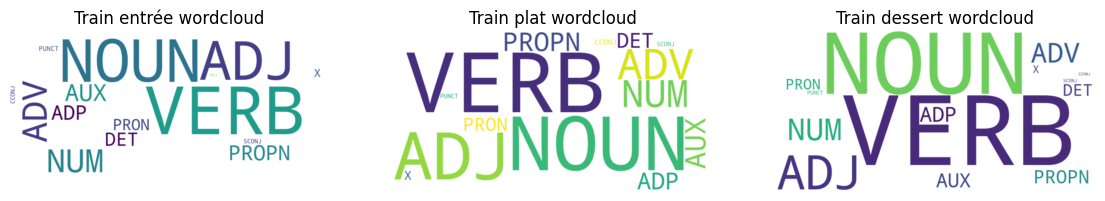

In [79]:
fig, axes = plt.subplots(1,3, figsize=(14,10))
axes[0].imshow(entree_wc, interpolation="bilinear")
axes[0].set_title("Train entrée wordcloud")
axes[0].axis("off")
axes[1].imshow(plat_wc, interpolation="bilinear")
axes[1].set_title("Train plat wordcloud")
axes[1].axis("off")
axes[2].imshow(dessert_wc, interpolation="bilinear")
axes[2].set_title("Train dessert wordcloud")
axes[2].axis("off")
fig.savefig("../outputs/train_wordcloud.png", dpi=300, bbox_inches="tight")

Les catégories de mots fréquents dans les plans de recettes sont: Les noms, verbes et adjectifs

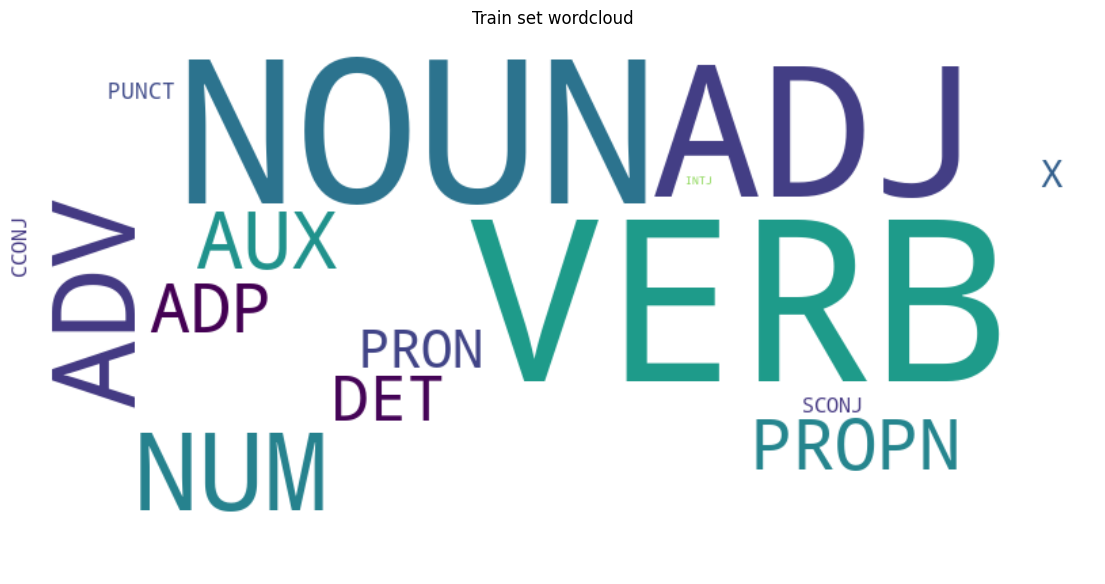

In [80]:
fig, ax = plt.subplots(1, 1, figsize=(14,10))
ax.imshow(entree_wc, interpolation="bilinear")
ax.set_title("Train set wordcloud")
ax.axis("off")
fig.savefig("../outputs/train_wordcloud2.png", dpi=300, bbox_inches="tight")

In [81]:
test = pd.read_csv("../data/test.csv", sep=",")

In [82]:
test["clean_recette"] = test['recette'].apply(lambda tw: ' '.join(spacy_tokenizer(tw, True, True, 1, False)[1]))
test["clean_ingredients"] = test['ingredients'].apply(lambda tw: ' '.join(spacy_tokenizer(tw, True, True, 1, False)[1]))

In [83]:
test.drop(columns=["doc_id"]).to_csv("../data/clean_test.csv", index=False)

In [2]:
test = pd.read_csv("../data/clean_test.csv")
train = pd.read_csv("../data/clean_train.csv")

In [7]:
train_data = pd.DataFrame({"recipe": train["titre"],
                     "title_length": train["titre"].apply(sentence_length),
                     "recipe_length": train["clean_recette"].apply(sentence_length),
                     "ingredients_length": train["clean_ingredients"].apply(sentence_length),
                     "recipe_freq_word": train["clean_recette"].apply(sentence_freq_word),
                     "number_of_ingredient": train["ingredients"].apply(count_ingredient),
                     "class": train["type"]
        })
train_data.head()

,recipe,title_length,recipe_length,ingredients_length,recipe_freq_word,number_of_ingredient,class
0,"Feuilleté de saumon et de poireau, sauce aux c...",9,107,35,poireau,13,Plat principal
1,Cake poulet/moutarde/amandes,2,56,40,faire,12,Entrée
2,Bûche à la truite fumée (7ème rencontre),7,77,20,mascarpone,6,Entrée
3,Gâteau au yaourt au coco sans huile de laetitia,9,25,25,mélanger,9,Dessert
4,Crêpes au canard laqué,4,145,56,ajouter,15,Entrée


In [9]:
train_data.to_csv("../data/train_numericals.csv", index=False)

In [8]:
test_data = pd.DataFrame({"recipe": test["titre"],
                     "title_length": test["titre"].apply(sentence_length),
                     "recipe_length": test["clean_recette"].apply(sentence_length),
                     "ingredients_length": test["clean_ingredients"].apply(sentence_length),
                     "recipe_freq_word": test["clean_recette"].apply(sentence_freq_word),
                     "number_of_ingredient": test["ingredients"].apply(count_ingredient),
                     "class": test["type"]
        })
test_data.head()

,recipe,title_length,recipe_length,ingredients_length,recipe_freq_word,number_of_ingredient,class
0,Roulé à la confiture de lait,6,77,24,lait,9,Dessert
1,Croissants aux amandes,3,132,49,pâte,15,Dessert
2,Quinoa Phileas (aux légumes croquants et sauci...,8,203,56,minute,16,Plat principal
3,Magret de canard à la crème de mûre,8,60,16,sauce,5,Plat principal
4,St-Jacques a la sauce aux huitres et aux asperges,9,81,28,asperge,10,Entrée


In [10]:
test_data.to_csv("../data/test_numericals.csv", index=False)